# 木材近赤外スペクトルによる含水率予測 - 分析・モデリング

## コンペ概要
- **タスク**: 回帰（木材の含水率を予測）
- **評価指標**: RMSE（小さいほど良い）
- **入力**: 近赤外スペクトル（10000〜4000 cm⁻¹、8 cm⁻¹分解能）
- **樹種**: 19種類

## 1. データ読み込み・基本確認

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'MS Gothic'

# データ読み込み（shift-jis）
train = pd.read_csv('../data/raw/train.csv', encoding='shift-jis')
test  = pd.read_csv('../data/raw/test.csv',  encoding='shift-jis')

print('=== train ===')
print(f'shape: {train.shape}')
print(f'columns (first 6): {list(train.columns[:6])}')
print(f'スペクトル列数: {train.shape[1] - 4}')

print('\n=== test ===')
print(f'shape: {test.shape}')
print(f'columns (first 6): {list(test.columns[:6])}')

print('\n=== 目的変数（含水率）の統計 ===')
print(train['含水率'].describe())

=== train ===
shape: (1322, 1559)
columns (first 6): ['sample number', 'species number', '樹種', '含水率', '9993.76781', '9989.9107']
スペクトル列数: 1555

=== test ===
shape: (550, 1558)
columns (first 6): ['sample number', 'species number', '樹種', '9993.76781', '9989.9107', '9986.05359']

=== 目的変数（含水率）の統計 ===
count    1322.000000
mean       49.937672
std        49.543466
min         0.840336
25%        16.114458
50%        29.052870
75%        70.264035
max       298.581560
Name: 含水率, dtype: float64


In [58]:
# 樹種別サンプル数
print('=== 樹種別サンプル数 ===')
print(train['樹種'].value_counts())

# 含水率の列と波数列の分離
META_COLS = ['sample number', 'species number', '樹種', '含水率']
WAVENUMBER_COLS = [c for c in train.columns if c not in META_COLS]
TARGET = '含水率'

print(f'\n波数列数: {len(WAVENUMBER_COLS)}')
print(f'波数範囲: {WAVENUMBER_COLS[-1]} 〜 {WAVENUMBER_COLS[0]} cm⁻¹')

=== 樹種別サンプル数 ===
樹種
トチ         183
ヒノキ        141
ベイスギ       112
ウォールナット    110
ナラ         107
スプルース       97
イチョウ        94
ベイマツ        93
クリ          91
チェリー        88
ウエンジ        87
米ヒバ         68
ホワイトオーク     51
Name: count, dtype: int64

波数列数: 1555
波数範囲: 3999.82139 〜 9993.76781 cm⁻¹


## 2. EDA（探索的データ分析）

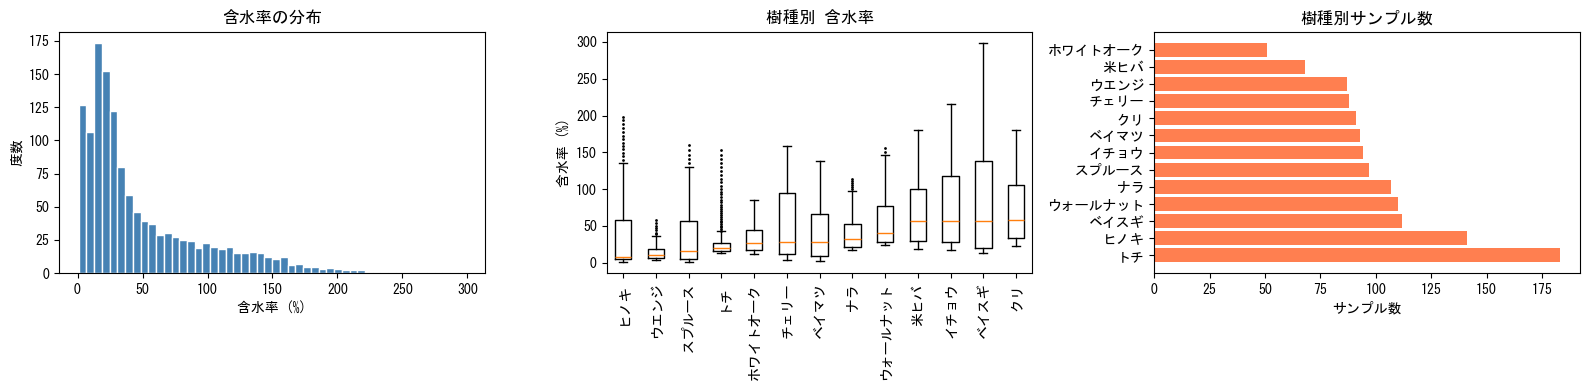

保存: data/interim/eda_target.png


In [59]:
import pathlib
pathlib.Path('../data/interim').mkdir(parents=True, exist_ok=True)
pathlib.Path('../data/processed').mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 含水率のヒストグラム
axes[0].hist(train[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('含水率の分布')
axes[0].set_xlabel('含水率 (%)')
axes[0].set_ylabel('度数')

# (2) 樹種別含水率 box plot（中央値でソート）
species_order = train.groupby('樹種')[TARGET].median().sort_values().index.tolist()
data_by_species = [train.loc[train['樹種'] == sp, TARGET].values for sp in species_order]
axes[1].boxplot(data_by_species, labels=species_order,
                flierprops=dict(marker='.', markersize=2))
axes[1].set_title('樹種別 含水率')
axes[1].set_xlabel('')
axes[1].set_ylabel('含水率 (%)')
axes[1].tick_params(axis='x', rotation=90)

# (3) 樹種別サンプル数
counts = train['樹種'].value_counts()
axes[2].barh(counts.index, counts.values, color='coral')
axes[2].set_title('樹種別サンプル数')
axes[2].set_xlabel('サンプル数')

plt.tight_layout()
plt.savefig('../data/interim/eda_target.png', dpi=100, bbox_inches='tight')
plt.show()
print('保存: data/interim/eda_target.png')

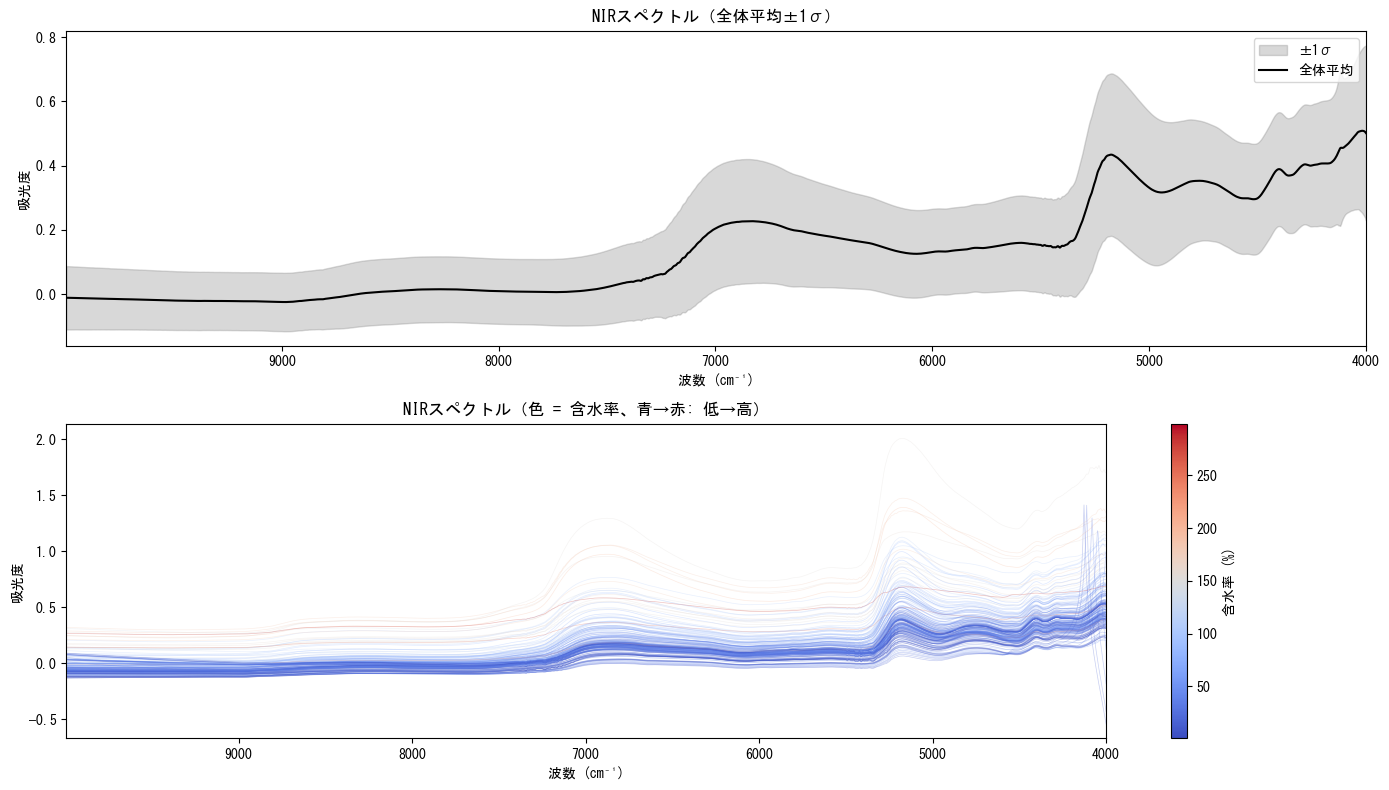

In [60]:
# NIRスペクトルの可視化（樹種ごとに平均スペクトル）
X_train = train[WAVENUMBER_COLS].values
wavenums = np.array([float(c) for c in WAVENUMBER_COLS])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 全サンプルの平均±std（灰色）
mean_spec = X_train.mean(axis=0)
std_spec  = X_train.std(axis=0)
axes[0].fill_between(wavenums, mean_spec - std_spec, mean_spec + std_spec,
                     alpha=0.3, color='gray', label='±1σ')
axes[0].plot(wavenums, mean_spec, color='black', lw=1.5, label='全体平均')
axes[0].set_xlim(wavenums.max(), wavenums.min())  # 波数は右→左
axes[0].set_title('NIRスペクトル（全体平均±1σ）')
axes[0].set_xlabel('波数 (cm⁻¹)')
axes[0].set_ylabel('吸光度')
axes[0].legend()

# 含水率でカラーマップ
sc = axes[1].scatter([], [], c=[], cmap='coolwarm')  # dummy for colorbar
for _, row in train.sample(min(200, len(train)), random_state=42).iterrows():
    spec = row[WAVENUMBER_COLS].values.astype(float)
    color = plt.cm.coolwarm(row[TARGET] / train[TARGET].max())
    axes[1].plot(wavenums, spec, color=color, alpha=0.3, lw=0.5)

axes[1].set_xlim(wavenums.max(), wavenums.min())
axes[1].set_title('NIRスペクトル（色 = 含水率、青→赤: 低→高）')
axes[1].set_xlabel('波数 (cm⁻¹)')
axes[1].set_ylabel('吸光度')
sm = plt.cm.ScalarMappable(cmap='coolwarm',
     norm=plt.Normalize(vmin=train[TARGET].min(), vmax=train[TARGET].max()))
plt.colorbar(sm, ax=axes[1], label='含水率 (%)')

plt.tight_layout()
plt.savefig('../data/interim/eda_spectra.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. 前処理：SNV（Standard Normal Variate）

NIRスペクトルには散乱・光路長変動の影響があるため、SNVで正規化する。  
SNV: 各スペクトルの平均を引き、標準偏差で割る（行単位の標準化）。

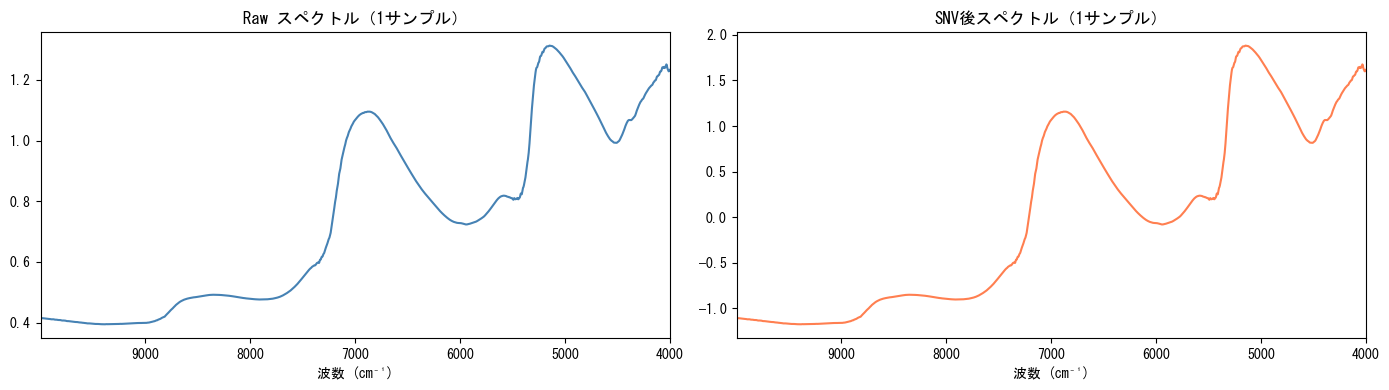

X_train_snv shape: (1322, 1555)
X_test_snv  shape: (550, 1555)


In [61]:
def snv(X):
    """Standard Normal Variate: 各サンプルを行単位で標準化"""
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / (std + 1e-10)

X_train_raw = train[WAVENUMBER_COLS].values.astype(float)
X_test_raw  = test[WAVENUMBER_COLS].values.astype(float)
y_train     = train[TARGET].values

X_train_snv = snv(X_train_raw)
X_test_snv  = snv(X_test_raw)

# SNV前後のスペクトル比較（1サンプル）
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(wavenums, X_train_raw[0], color='steelblue')
axes[0].set_xlim(wavenums.max(), wavenums.min())
axes[0].set_title('Raw スペクトル（1サンプル）')
axes[0].set_xlabel('波数 (cm⁻¹)')

axes[1].plot(wavenums, X_train_snv[0], color='coral')
axes[1].set_xlim(wavenums.max(), wavenums.min())
axes[1].set_title('SNV後スペクトル（1サンプル）')
axes[1].set_xlabel('波数 (cm⁻¹)')

plt.tight_layout()
plt.show()
print(f'X_train_snv shape: {X_train_snv.shape}')
print(f'X_test_snv  shape: {X_test_snv.shape}')

## 4. 特徴量エンジニアリング：PCA次元削減

スペクトル列数が700以上と多次元なため、PCAで主成分に変換する。  
trainデータのみでfitし、testはtransformする（ルール遵守）。

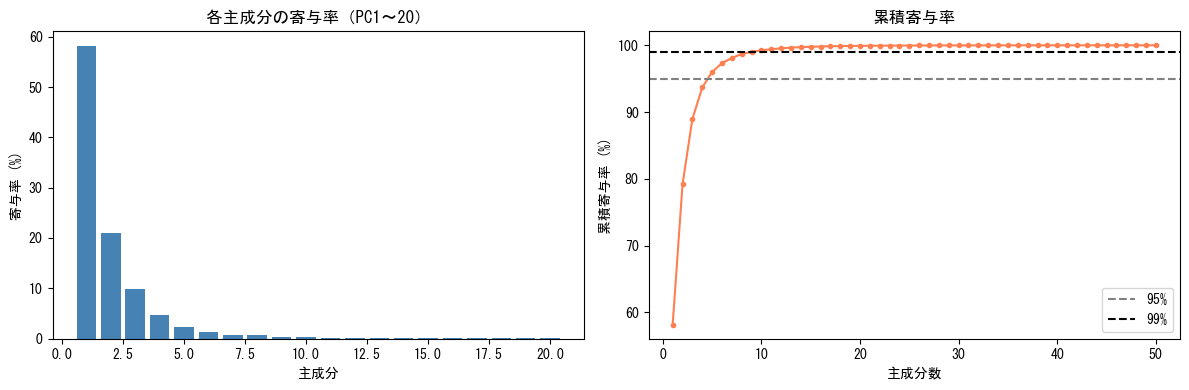

95%説明に必要な主成分数: 5
99%説明に必要な主成分数: 10
PC1〜5の累積寄与率: 0.9600


In [62]:
from sklearn.decomposition import PCA

# trainのみでPCAをfit
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_snv)
X_test_pca  = pca.transform(X_test_snv)

# 寄与率の確認
cumvar = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 21), pca.explained_variance_ratio_[:20] * 100, color='steelblue')
axes[0].set_title('各主成分の寄与率（PC1〜20）')
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('寄与率 (%)')

axes[1].plot(range(1, 51), cumvar * 100, marker='o', markersize=3, color='coral')
axes[1].axhline(95, color='gray', linestyle='--', label='95%')
axes[1].axhline(99, color='black', linestyle='--', label='99%')
axes[1].set_title('累積寄与率')
axes[1].set_xlabel('主成分数')
axes[1].set_ylabel('累積寄与率 (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

n95 = np.searchsorted(cumvar, 0.95) + 1
n99 = np.searchsorted(cumvar, 0.99) + 1
print(f'95%説明に必要な主成分数: {n95}')
print(f'99%説明に必要な主成分数: {n99}')
print(f'PC1〜5の累積寄与率: {cumvar[4]:.4f}')

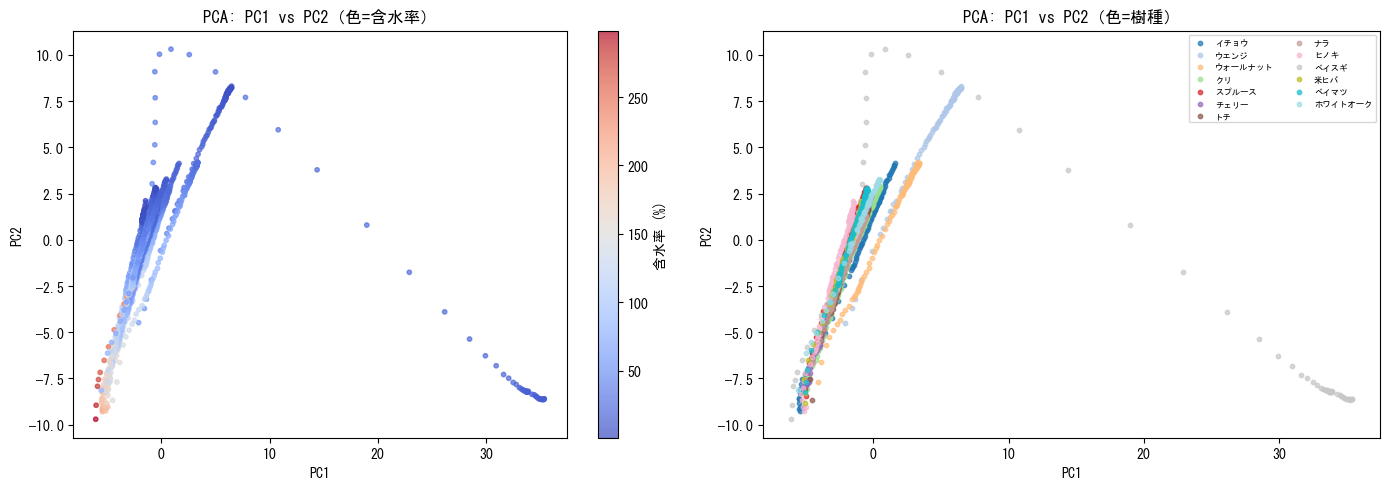

In [63]:
# PC1 vs PC2 の散布図（含水率でカラーリング）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='coolwarm', s=10, alpha=0.7)
plt.colorbar(sc1, ax=axes[0], label='含水率 (%)')
axes[0].set_title('PCA: PC1 vs PC2（色=含水率）')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# 樹種でカラーリング
species_list = train['樹種'].unique()
colors2 = plt.cm.tab20(np.linspace(0, 1, len(species_list)))
for i, sp in enumerate(species_list):
    mask = train['樹種'].values == sp
    axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    label=sp, color=colors2[i], s=10, alpha=0.7)
axes[1].set_title('PCA: PC1 vs PC2（色=樹種）')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=6, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

## 5. モデル構築

### 戦略
- **特徴量**: SNV正規化 + PCA（50次元）+ 樹種番号（カテゴリ）
- **モデル**: LightGBM（回帰）
- **検証**: GroupKFold（同一サンプル番号をグループとして情報リークを防ぐ）
- **評価指標**: RMSE

In [64]:
import lightgbm as lgb
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_squared_error

# 特徴量: PCA50次元 + 樹種番号
X_feat = np.hstack([
    X_train_pca,
    train['species number'].values.reshape(-1, 1)
])
X_feat_test = np.hstack([
    X_test_pca,
    test['species number'].values.reshape(-1, 1)
])

print(f'学習特徴量 shape: {X_feat.shape}')
print(f'テスト特徴量 shape: {X_feat_test.shape}')

学習特徴量 shape: (1322, 51)
テスト特徴量 shape: (550, 51)


In [65]:
# GroupKFold: sample number をグループに（同一木材の測定が同じfoldに入る）
groups = train['sample number'].values

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 10,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'random_state': 42,
}

N_FOLDS = 5
kf = GroupKFold(n_splits=N_FOLDS)

oof_preds = np.zeros(len(X_feat))
test_preds = np.zeros(len(X_feat_test))
fold_rmses = []
models = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_feat, y_train, groups)):
    X_tr, X_val = X_feat[tr_idx], X_feat[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)],
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_feat_test) / N_FOLDS

    rmse = mean_squared_error(y_val, val_pred, squared=False)
    fold_rmses.append(rmse)
    models.append(model)
    print(f'  Fold {fold+1}: RMSE = {rmse:.4f}')

overall_rmse = mean_squared_error(y_train, oof_preds, squared=False)
print(f'\n=== OOF RMSE: {overall_rmse:.4f} ===')
print(f'各foldの平均: {np.mean(fold_rmses):.4f} ± {np.std(fold_rmses):.4f}')

Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 4.99069
Early stopping, best iteration is:
[699]	valid_0's rmse: 4.97728
  Fold 1: RMSE = 4.9773
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 4.24559
[1000]	valid_0's rmse: 4.15503
[1500]	valid_0's rmse: 4.14032
[2000]	valid_0's rmse: 4.136
Did not meet early stopping. Best iteration is:
[1917]	valid_0's rmse: 4.13598
  Fold 2: RMSE = 4.1360
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 4.11698
[1000]	valid_0's rmse: 4.0821
Early stopping, best iteration is:
[1265]	valid_0's rmse: 4.07816
  Fold 3: RMSE = 4.0782
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 7.09699
Early stopping, best iteration is:
[670]	valid_0's rmse: 7.04235
  Fold 4: RMSE = 7.0423
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 4.50937
Early stopping, best iteration is:
[445]	valid_0

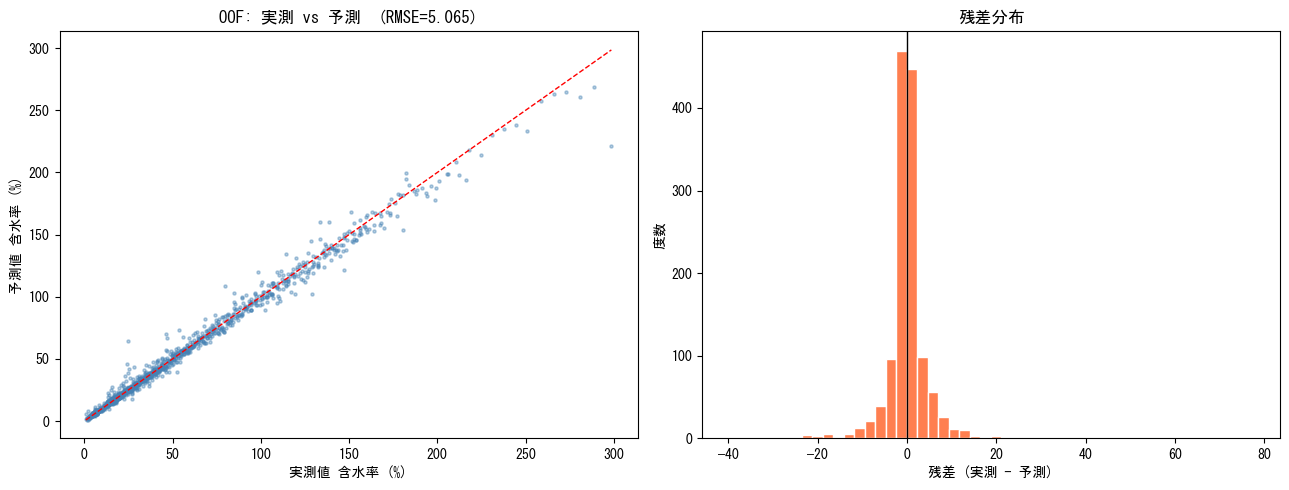

残差: mean=0.0773, std=5.0647


In [66]:
# OOF予測の可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_train, oof_preds, s=5, alpha=0.4, color='steelblue')
lim = [min(y_train.min(), oof_preds.min()), max(y_train.max(), oof_preds.max())]
axes[0].plot(lim, lim, color='red', lw=1, linestyle='--')
axes[0].set_title(f'OOF: 実測 vs 予測  (RMSE={overall_rmse:.3f})')
axes[0].set_xlabel('実測値 含水率 (%)')
axes[0].set_ylabel('予測値 含水率 (%)')

residuals = y_train - oof_preds
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('残差分布')
axes[1].set_xlabel('残差 (実測 - 予測)')
axes[1].set_ylabel('度数')

plt.tight_layout()
plt.show()

print(f'残差: mean={residuals.mean():.4f}, std={residuals.std():.4f}')

## 6. submission 生成

In [67]:
# sample_submit.csv の形式を確認（header=None で正しく読む）
sample_sub = pd.read_csv('../data/raw/sample_submit.csv', encoding='shift-jis', header=None)
print('sample_submit.csv:')
print(sample_sub.head())
print(f'sample_sub shape: {sample_sub.shape}')
print(f'test shape:       {test.shape}')
print(f'test_preds len:   {len(test_preds)}')

# submission 作成（列名なし、sample numberと予測値）
sub = pd.DataFrame({
    0: test['sample number'].values,
    1: test_preds,
})

sub.to_csv('../data/processed/submission_lgbm_v1.csv', index=False, header=False, encoding='shift-jis')
print('\n保存: data/processed/submission_lgbm_v1.csv')
print(sub.head(10))

sample_submit.csv:
    0   1
0  95  50
1  96  50
2  97  50
3  98  50
4  99  50
sample_sub shape: (550, 2)
test shape:       (550, 1558)
test_preds len:   550

保存: data/processed/submission_lgbm_v1.csv
     0           1
0   95  174.648614
1   96  177.839502
2   97  163.540443
3   98  157.375004
4   99  151.947825
5  100  142.027158
6  101  142.134475
7  102  137.282195
8  103  130.395298
9  104  130.495497


## まとめ・次のステップ

### 今回の構成
| ステップ | 内容 |
|---|---|
| 前処理 | SNV（散乱補正） |
| 特徴量 | PCA 50次元 + 樹種番号 |
| モデル | LightGBM (GroupKFold 5-fold) |
| 評価 | OOF RMSE |

### 改善アイデア
1. **前処理**: 2次微分（SG法）でさらにベースライン除去
2. **特徴量**: SNV後の生スペクトルをそのまま入力（次元削減なし）
3. **モデル**: PLSR（Partial Least Squares Regression）— NIRでは定番
4. **樹種別モデル**: 樹種ごとにモデルを分けて学習
5. **アンサンブル**: LightGBM + PLSR + Ridge のブレンド
6. **GroupKFold改善**: sample numberではなく樹種でグループ化

## 7. 再学習：樹種単位の分割 & ベイスギ除外

In [68]:
# ベイスギを除外
train_v2 = train[train['樹種'] != 'ベイスギ'].reset_index(drop=True)
print(f'除外前: {len(train)} サンプル')
print(f'除外後: {len(train_v2)} サンプル（ベイスギ {len(train) - len(train_v2)} 件を除外）')
print(f'\n樹種数: {train_v2["樹種"].nunique()}')
print(train_v2['樹種'].value_counts())

# 特徴量を再構築（SNV → PCA はtrainのみでfit）
X_train_raw_v2 = train_v2[WAVENUMBER_COLS].values.astype(float)
y_train_v2     = train_v2[TARGET].values

X_train_snv_v2 = snv(X_train_raw_v2)

pca_v2 = PCA(n_components=50, random_state=42)
X_train_pca_v2 = pca_v2.fit_transform(X_train_snv_v2)
X_test_pca_v2  = pca_v2.transform(snv(X_test_raw))

X_feat_v2 = np.hstack([
    X_train_pca_v2,
    train_v2['species number'].values.reshape(-1, 1)
])
X_feat_test_v2 = np.hstack([
    X_test_pca_v2,
    test['species number'].values.reshape(-1, 1)
])
print(f'\n学習特徴量 shape: {X_feat_v2.shape}')

除外前: 1322 サンプル
除外後: 1210 サンプル（ベイスギ 112 件を除外）

樹種数: 12
樹種
トチ         183
ヒノキ        141
ウォールナット    110
ナラ         107
スプルース       97
イチョウ        94
ベイマツ        93
クリ          91
チェリー        88
ウエンジ        87
米ヒバ         68
ホワイトオーク     51
Name: count, dtype: int64

学習特徴量 shape: (1210, 51)


In [69]:
# 樹種単位のGroupKFold（18樹種 → 5fold）
groups_v2 = train_v2['species number'].values

oof_preds_v2  = np.zeros(len(X_feat_v2))
test_preds_v2 = np.zeros(len(X_feat_test_v2))
fold_rmses_v2 = []
models_v2     = []

kf_v2 = GroupKFold(n_splits=5)

for fold, (tr_idx, val_idx) in enumerate(kf_v2.split(X_feat_v2, y_train_v2, groups_v2)):
    X_tr, X_val = X_feat_v2[tr_idx], X_feat_v2[val_idx]
    y_tr, y_val = y_train_v2[tr_idx], y_train_v2[val_idx]

    # validationに含まれる樹種を表示
    val_species = train_v2.iloc[val_idx]['樹種'].unique().tolist()
    print(f'Fold {fold+1} validation 樹種: {val_species}')

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)],
    )

    val_pred = model.predict(X_val)
    oof_preds_v2[val_idx] = val_pred
    test_preds_v2 += model.predict(X_feat_test_v2) / 5

    rmse = mean_squared_error(y_val, val_pred, squared=False)
    fold_rmses_v2.append(rmse)
    models_v2.append(model)
    print(f'  → RMSE = {rmse:.4f}\n')

overall_rmse_v2 = mean_squared_error(y_train_v2, oof_preds_v2, squared=False)
print(f'=== OOF RMSE (v2): {overall_rmse_v2:.4f} ===')
print(f'各foldの平均: {np.mean(fold_rmses_v2):.4f} ± {np.std(fold_rmses_v2):.4f}')
print(f'\n比較: v1 (sample分割) = {overall_rmse:.4f}  →  v2 (樹種分割) = {overall_rmse_v2:.4f}')

Fold 1 validation 樹種: ['ウエンジ', 'トチ']
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[21]	valid_0's rmse: 26.6668
  → RMSE = 26.6668

Fold 2 validation 樹種: ['チェリー', 'ヒノキ']
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 25.4458
Early stopping, best iteration is:
[497]	valid_0's rmse: 25.445
  → RMSE = 25.4450

Fold 3 validation 樹種: ['ウォールナット', 'クリ']
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 19.4274
Early stopping, best iteration is:
[575]	valid_0's rmse: 19.4066
  → RMSE = 19.4066

Fold 4 validation 樹種: ['ナラ', 'ベイマツ', 'ホワイトオーク']
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[39]	valid_0's rmse: 10.3378
  → RMSE = 10.3378

Fold 5 validation 樹種: ['イチョウ', 'スプルース', '米ヒバ']
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[215]	valid_0's rmse: 23.7723
  → RMSE = 23.7723

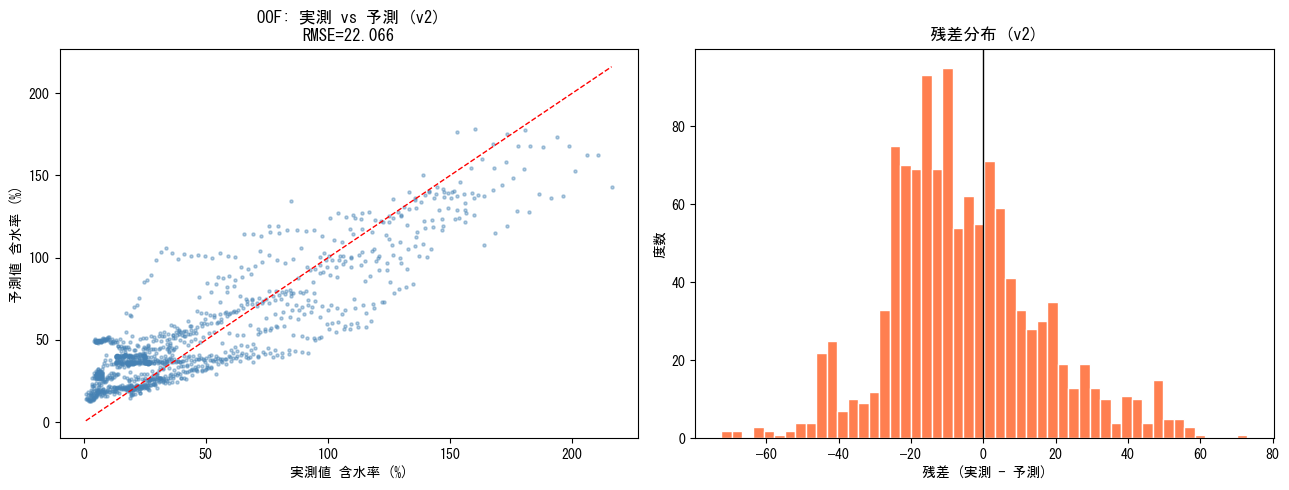

保存: data/processed/submission_lgbm_v2.csv
     0           1
0   95  159.563278
1   96  134.324908
2   97  124.829484
3   98  122.554503
4   99  120.331996
5  100  117.603453
6  101  118.096016
7  102  116.310870
8  103  115.608809
9  104  111.956319


In [70]:
# OOF予測の可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_train_v2, oof_preds_v2, s=5, alpha=0.4, color='steelblue')
lim = [min(y_train_v2.min(), oof_preds_v2.min()), max(y_train_v2.max(), oof_preds_v2.max())]
axes[0].plot(lim, lim, color='red', lw=1, linestyle='--')
axes[0].set_title(f'OOF: 実測 vs 予測 (v2)\nRMSE={overall_rmse_v2:.3f}')
axes[0].set_xlabel('実測値 含水率 (%)')
axes[0].set_ylabel('予測値 含水率 (%)')

residuals_v2 = y_train_v2 - oof_preds_v2
axes[1].hist(residuals_v2, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('残差分布 (v2)')
axes[1].set_xlabel('残差 (実測 - 予測)')
axes[1].set_ylabel('度数')

plt.tight_layout()
plt.show()

# submission 保存（ヘッダーなし）
sub_v2 = pd.DataFrame({
    0: test['sample number'].values,
    1: test_preds_v2,
})
sub_v2.to_csv('../data/processed/submission_lgbm_v2.csv', index=False, header=False, encoding='shift-jis')
print('保存: data/processed/submission_lgbm_v2.csv')
print(sub_v2.head(10))

## 8. 前処理改善：SG法（Savitzky-Golay）2次微分

SNV後にSG 2次微分を適用してベースラインのオフセット・傾きを除去する。  
- `window_length=11`（奇数）、`polyorder=2`、`deriv=2`
- 行単位の処理なのでtrain/testで共通適用できる（ルール遵守）

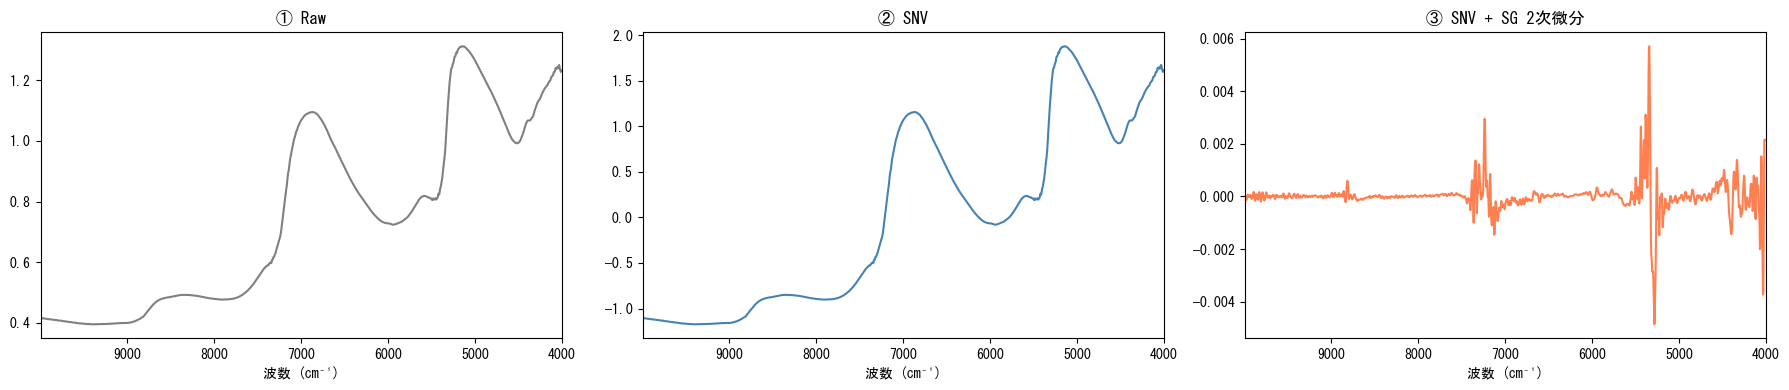

X_train_sg shape: (1210, 1555)
X_test_sg  shape: (550, 1555)


In [71]:
from scipy.signal import savgol_filter

def sg2(X, window_length=11, polyorder=2):
    """Savitzky-Golay 2次微分（行単位）"""
    return savgol_filter(X, window_length=window_length, polyorder=polyorder, deriv=2, axis=1)

# ベイスギ除外済みデータに SNV → SG2 を適用
X_train_sg = sg2(X_train_snv_v2)   # train_v2 ベース
X_test_sg  = sg2(snv(X_test_raw))

# 前処理比較（1サンプル）
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(wavenums, X_train_raw_v2[0], color='gray')
axes[0].set_title('① Raw')
axes[0].set_xlim(wavenums.max(), wavenums.min())
axes[0].set_xlabel('波数 (cm⁻¹)')

axes[1].plot(wavenums, X_train_snv_v2[0], color='steelblue')
axes[1].set_title('② SNV')
axes[1].set_xlim(wavenums.max(), wavenums.min())
axes[1].set_xlabel('波数 (cm⁻¹)')

axes[2].plot(wavenums, X_train_sg[0], color='coral')
axes[2].set_title('③ SNV + SG 2次微分')
axes[2].set_xlim(wavenums.max(), wavenums.min())
axes[2].set_xlabel('波数 (cm⁻¹)')

plt.tight_layout()
plt.show()
print(f'X_train_sg shape: {X_train_sg.shape}')
print(f'X_test_sg  shape: {X_test_sg.shape}')

## 9. モデル：PLSR（Partial Least Squares Regression）

NIR分光×化学量予測の定番手法。スペクトルの共線性に強く、少ない潜在変数で高精度を出しやすい。  
- 入力: SNV + SG2次微分後スペクトル（次元削減不要）
- CV: 樹種単位 GroupKFold 5-fold（v2と同条件）
- 潜在変数数 `n_components` はCVで探索

n_components=  5  OOF RMSE=18.0012
n_components= 10  OOF RMSE=17.9468
n_components= 15  OOF RMSE=20.2598
n_components= 20  OOF RMSE=20.1272
n_components= 25  OOF RMSE=19.6758
n_components= 30  OOF RMSE=20.1639

最適 n_components: 10  (RMSE=17.9468)


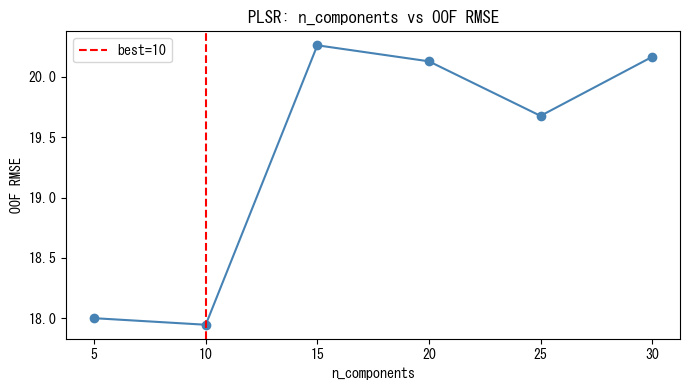

In [ ]:
from sklearn.cross_decomposition import PLSRegression

# n_components の探索（CV内でfitするため、外側のCVで評価）
n_components_list = [5, 10, 15, 20, 25, 30]
cv_rmse_by_nc = {}

for nc in n_components_list:
    oof_tmp = np.zeros(len(X_train_sg))
    for tr_idx, val_idx in kf_v2.split(X_train_sg, y_train_v2, groups_v2):
        pls = PLSRegression(n_components=nc, max_iter=500)
        pls.fit(X_train_sg[tr_idx], y_train_v2[tr_idx])
        oof_tmp[val_idx] = pls.predict(X_train_sg[val_idx]).ravel()
    rmse = mean_squared_error(y_train_v2, oof_tmp, squared=False)
    cv_rmse_by_nc[nc] = rmse
    print(f'n_components={nc:3d}  OOF RMSE={rmse:.4f}')

best_nc = min(cv_rmse_by_nc, key=cv_rmse_by_nc.get)
print(f'\n最適 n_components: {best_nc}  (RMSE={cv_rmse_by_nc[best_nc]:.4f})')

plt.figure(figsize=(7, 4))
plt.plot(list(cv_rmse_by_nc.keys()), list(cv_rmse_by_nc.values()), marker='o', color='steelblue')
plt.axvline(best_nc, color='red', linestyle='--', label=f'best={best_nc}')
plt.xlabel('n_components')
plt.ylabel('OOF RMSE')
plt.title('PLSR: n_components vs OOF RMSE')
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# 最適 n_components で本番CV → OOF予測・テスト予測
oof_preds_plsr  = np.zeros(len(X_train_sg))
test_preds_plsr = np.zeros(len(X_test_sg))
fold_rmses_plsr = []

for fold, (tr_idx, val_idx) in enumerate(kf_v2.split(X_train_sg, y_train_v2, groups_v2)):
    val_species = train_v2.iloc[val_idx]['樹種'].unique().tolist()

    pls = PLSRegression(n_components=best_nc, max_iter=500)
    pls.fit(X_train_sg[tr_idx], y_train_v2[tr_idx])

    val_pred = pls.predict(X_train_sg[val_idx]).ravel()
    oof_preds_plsr[val_idx] = val_pred
    test_preds_plsr += pls.predict(X_test_sg).ravel() / 5

    rmse = mean_squared_error(y_train_v2[val_idx], val_pred, squared=False)
    fold_rmses_plsr.append(rmse)
    print(f'Fold {fold+1} {val_species}  RMSE={rmse:.4f}')

overall_rmse_plsr = mean_squared_error(y_train_v2, oof_preds_plsr, squared=False)
print(f'\n=== OOF RMSE ===')
print(f'  v1  (LGB / sample分割):   {overall_rmse:.4f}')
print(f'  v2  (LGB / 樹種分割):     {overall_rmse_v2:.4f}')
print(f'  v3  (PLSR / 樹種分割):    {overall_rmse_plsr:.4f}')

Fold 1 ['ウエンジ', 'トチ']  RMSE=17.6819
Fold 2 ['チェリー', 'ヒノキ']  RMSE=15.2168
Fold 3 ['ウォールナット', 'クリ']  RMSE=17.5539
Fold 4 ['ナラ', 'ベイマツ', 'ホワイトオーク']  RMSE=21.2275
Fold 5 ['イチョウ', 'スプルース', '米ヒバ']  RMSE=17.2701

=== OOF RMSE ===
  v1  (LGB / sample分割):   5.0653
  v2  (LGB / 樹種分割):     22.0660
  v3  (PLSR / 樹種分割):    17.9468


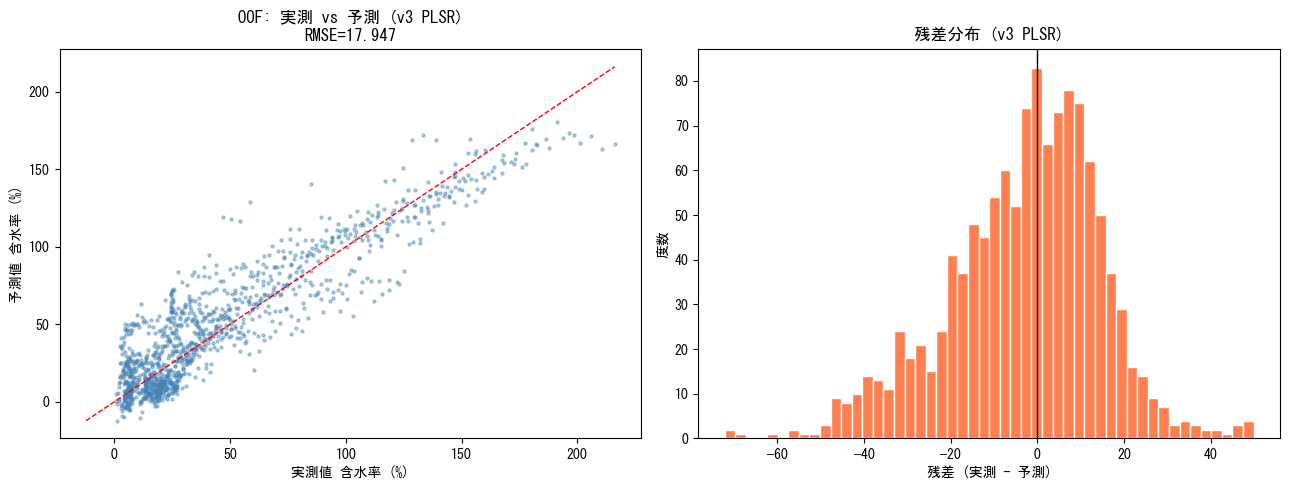

保存: data/processed/submission_lgbm_v3.csv
     0           1
0   95  169.516705
1   96  143.997492
2   97  150.958565
3   98  142.924190
4   99  140.137751
5  100  130.660299
6  101  139.139045
7  102  137.100959
8  103  130.856581
9  104  133.572201


In [74]:
# OOF可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_train_v2, oof_preds_plsr, s=5, alpha=0.4, color='steelblue')
lim = [min(y_train_v2.min(), oof_preds_plsr.min()), max(y_train_v2.max(), oof_preds_plsr.max())]
axes[0].plot(lim, lim, color='red', lw=1, linestyle='--')
axes[0].set_title(f'OOF: 実測 vs 予測 (v3 PLSR)\nRMSE={overall_rmse_plsr:.3f}')
axes[0].set_xlabel('実測値 含水率 (%)')
axes[0].set_ylabel('予測値 含水率 (%)')

residuals_plsr = y_train_v2 - oof_preds_plsr
axes[1].hist(residuals_plsr, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('残差分布 (v3 PLSR)')
axes[1].set_xlabel('残差 (実測 - 予測)')
axes[1].set_ylabel('度数')

plt.tight_layout()
plt.show()

# submission 保存
sub_v3 = pd.DataFrame({
    0: test['sample number'].values,
    1: test_preds_plsr,
})
sub_v3.to_csv('../data/processed/submission_lgbm_v3.csv', index=False, header=False, encoding='shift-jis')
print('保存: data/processed/submission_lgbm_v3.csv')
print(sub_v3.head(10))